# Phase 6: Customer Lifetime Value (CLV) Prediction

# Section 1.1: Import Required Libraries

## Objective

In this step, we import all the Python libraries required throughout the Customer Lifetime Value (CLV) prediction pipeline.

These libraries provide functionality for data manipulation, visualization, machine learning, model evaluation, and model persistence. Importing all required libraries at the beginning of the notebook keeps the workflow organized and ensures that the necessary tools are readily available for the subsequent sections.

In [1]:
# ============================================================
# Section 1.1: Import Required Libraries
# ============================================================

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Saving
import joblib

In [2]:
# ============================================================
# Section 1.2: Import Machine Learning Libraries
# ============================================================

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# ============================================================
# Section 1.3: Configure Notebook Settings
# ============================================================

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Plot Settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [4]:
# ============================================================
# Section 1.4: Load Customer Segments Dataset
# ============================================================

# Load the processed customer dataset generated in Phase 5
customer_df = pd.read_csv("../data/processed/customer_segments.csv")

print("=" * 70)
print("Customer Segments Dataset Loaded Successfully")
print("=" * 70)

Customer Segments Dataset Loaded Successfully


In [5]:
# ============================================================
# Section 1.5: Initial Dataset Inspection
# ============================================================

print(f"Dataset Shape: {customer_df.shape}")

print("\nFirst Five Rows:")
display(customer_df.head())

print("\nColumn Names:")
display(customer_df.columns.tolist())

print("\nMissing Values:")
display(customer_df.isnull().sum())

print("\nData Types:")
display(customer_df.dtypes)

Dataset Shape: (5878, 28)

First Five Rows:


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,MedianRevenue,MaxRevenue,MinRevenue,RevenueSTD,RevenueRange,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,Cluster,CustomerSegment
0,12346.00,326,12,77556.46,74285,2184.85,1.00,74215,1,12727.40,6463.04,22.50,77183.60,1.00,22271.23,77182.60,27,2.83,4,400,0.00,35.91,5.00,-77608.20,29.41,United Kingdom,2,Exceptional High-Value Customer
1,12347.00,2,8,4921.53,2967,13.36,12.00,240,2,17.34,615.19,598.22,1294.32,224.82,315.77,1069.50,126,27.75,6,402,18.02,57.00,0.00,0.00,0.00,Iceland,3,At-Risk Customers
2,12348.00,75,5,2019.40,2714,53.22,24.00,144,1,48.70,403.88,310.00,892.80,222.16,279.90,670.64,25,9.40,4,362,5.88,90.50,0.00,0.00,0.00,Finland,3,At-Risk Customers
3,12349.00,19,4,4428.69,1624,9.28,6.00,48,1,7.77,1107.17,1235.57,1757.55,200.00,667.02,1557.55,138,43.75,4,570,0.00,189.67,1.00,-24.15,20.00,Italy,3,At-Risk Customers
4,12350.00,310,1,334.40,197,11.59,12.00,24,1,4.35,334.40,334.40,334.40,334.40,0.00,0.00,17,17.00,1,0,0.00,0.00,0.00,0.00,0.00,Norway,0,VIP Customers



Column Names:


['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'TotalQuantity',
 'AvgQuantity',
 'MedianQuantity',
 'MaxQuantity',
 'MinQuantity',
 'QuantitySTD',
 'AvgRevenue',
 'MedianRevenue',
 'MaxRevenue',
 'MinRevenue',
 'RevenueSTD',
 'RevenueRange',
 'UniqueProducts',
 'AvgProductsPerInvoice',
 'ActiveMonths',
 'PurchaseSpan',
 'WeekendPurchaseRate',
 'AvgDaysBetweenPurchases',
 'CancelledTransactions',
 'CancelledRevenue',
 'CancellationRate',
 'Country',
 'Cluster',
 'CustomerSegment']


Missing Values:


CustomerID                 0
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AvgQuantity                0
MedianQuantity             0
MaxQuantity                0
MinQuantity                0
QuantitySTD                0
AvgRevenue                 0
MedianRevenue              0
MaxRevenue                 0
MinRevenue                 0
RevenueSTD                 0
RevenueRange               0
UniqueProducts             0
AvgProductsPerInvoice      0
ActiveMonths               0
PurchaseSpan               0
WeekendPurchaseRate        0
AvgDaysBetweenPurchases    0
CancelledTransactions      0
CancelledRevenue           0
CancellationRate           0
Country                    0
Cluster                    0
CustomerSegment            0
dtype: int64


Data Types:


CustomerID                 float64
Recency                      int64
Frequency                    int64
Monetary                   float64
TotalQuantity                int64
AvgQuantity                float64
MedianQuantity             float64
MaxQuantity                  int64
MinQuantity                  int64
QuantitySTD                float64
AvgRevenue                 float64
MedianRevenue              float64
MaxRevenue                 float64
MinRevenue                 float64
RevenueSTD                 float64
RevenueRange               float64
UniqueProducts               int64
AvgProductsPerInvoice      float64
ActiveMonths                 int64
PurchaseSpan                 int64
WeekendPurchaseRate        float64
AvgDaysBetweenPurchases    float64
CancelledTransactions      float64
CancelledRevenue           float64
CancellationRate           float64
Country                     object
Cluster                      int64
CustomerSegment             object
dtype: object

## Section Summary

In this section, we initialized the Customer Lifetime Value prediction phase by importing all the required Python libraries and loading the final customer-level dataset generated during the customer segmentation phase.

A preliminary inspection of the dataset was performed to verify its structure, data types, feature availability, and missing values. This validation step ensures that the dataset is complete and suitable for predictive modeling before any feature selection or target variable creation begins.

The successful loading of the dataset confirms that the engineered customer features from previous phases are now ready to be used as input variables for building Customer Lifetime Value prediction models in the upcoming sections.

# Section 2: Dataset Overview & Initial Exploration

## Objective

Before building any machine learning model, it is essential to thoroughly understand the dataset that will be used for training.

In this section, we perform an initial exploration of the customer-level dataset generated during the customer segmentation phase. This helps us verify that all engineered features have been correctly created and identify any potential issues before proceeding with Customer Lifetime Value (CLV) prediction.

Understanding the dataset is a crucial step because the quality of the input data directly impacts the performance of the predictive model.

---

## Why This Step is Important

A machine learning model can only learn meaningful patterns if the input data is accurate, complete, and representative of customer behavior.

By examining the dataset, we can:

- Verify the number of customers available for analysis.
- Understand the available customer-level features.
- Review the statistical distribution of numerical variables.
- Identify categorical features.
- Detect missing values or unexpected data issues.
- Gain confidence that the dataset is ready for predictive modeling.

This exploratory step also helps us understand which customer characteristics may influence future customer value.

---

## Expected Outcome

By the end of this section, we will have a clear understanding of the dataset's structure, feature types, and overall quality, providing a solid foundation for creating the Customer Lifetime Value (CLV) target variable in the next section.

In [6]:
# ============================================================
# Section 2.1: Dataset Information
# ============================================================

print("=" * 70)
print("Dataset Overview")
print("=" * 70)

print(f"\nNumber of Customers : {customer_df.shape[0]}")
print(f"Number of Features  : {customer_df.shape[1]}")

print("\nDataset Information:")
customer_df.info()

Dataset Overview

Number of Customers : 5878
Number of Features  : 28

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Recency                  5878 non-null   int64  
 2   Frequency                5878 non-null   int64  
 3   Monetary                 5878 non-null   float64
 4   TotalQuantity            5878 non-null   int64  
 5   AvgQuantity              5878 non-null   float64
 6   MedianQuantity           5878 non-null   float64
 7   MaxQuantity              5878 non-null   int64  
 8   MinQuantity              5878 non-null   int64  
 9   QuantitySTD              5878 non-null   float64
 10  AvgRevenue               5878 non-null   float64
 11  MedianRevenue            5878 non-null   float64
 12  MaxRevenue               5878 non-null  

In [7]:
# ============================================================
# Section 2.2: Statistical Summary
# ============================================================

print("Statistical Summary of Numerical Features:\n")

display(customer_df.describe().T)

Statistical Summary of Numerical Features:



,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.00,15315.31,1715.57,12346.00,13833.25,15314.50,16797.75,18287.00
Recency,5878.00,201.33,209.34,1.00,26.00,96.00,380.00,739.00
Frequency,5878.00,6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,5878.00,2955.90,14440.85,2.95,342.28,867.74,2248.30,580987.04
TotalQuantity,5878.00,1788.70,8876.30,1.00,187.00,480.00,1350.00,367193.00
AvgQuantity,5878.00,25.32,365.07,1.00,5.65,9.60,14.18,26999.00
MedianQuantity,5878.00,15.75,77.11,1.00,3.00,7.00,12.00,2520.00
MaxQuantity,5878.00,122.59,1485.33,1.00,24.00,48.00,80.00,80995.00
MinQuantity,5878.00,6.07,48.76,1.00,1.00,1.00,2.00,1440.00
QuantitySTD,5878.00,27.40,637.33,0.00,4.86,7.64,12.96,46761.91


In [8]:
# ============================================================
# Section 2.3: Categorical Features
# ============================================================

categorical_columns = customer_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Features:\n")
print(categorical_columns)

print("\nCategorical Feature Summary:\n")

display(customer_df[categorical_columns].describe())

Categorical Features:

['Country', 'CustomerSegment']

Categorical Feature Summary:



,Country,CustomerSegment
count,5878,5878
unique,41,4
top,United Kingdom,VIP Customers
freq,5350,3242


In [9]:
# ============================================================
# Section 2.4: Missing Value Analysis
# ============================================================

missing_values = (
    customer_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

missing_values["Missing Percentage"] = (
    missing_values["Missing Values"] / len(customer_df)
) * 100

display(missing_values)

,Missing Values,Missing Percentage
CustomerID,0,0.00
Recency,0,0.00
Frequency,0,0.00
Monetary,0,0.00
TotalQuantity,0,0.00
AvgQuantity,0,0.00
MedianQuantity,0,0.00
MaxQuantity,0,0.00
MinQuantity,0,0.00
QuantitySTD,0,0.00


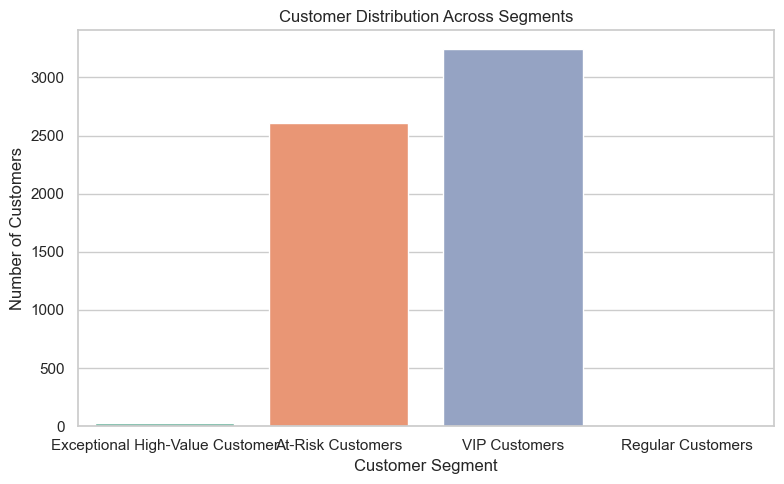

In [10]:
# ============================================================
# Section 2.5: Customer Segment Distribution
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_df,
    x="CustomerSegment",
    palette="Set2"
)

plt.title("Customer Distribution Across Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/customer_segment_distribution_phase6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Section Summary

In this section, we performed an initial exploration of the customer-level dataset to understand its structure and verify its readiness for machine learning.

We examined the overall dataset dimensions, reviewed descriptive statistics for numerical features, identified categorical variables, checked for missing values, and analyzed the distribution of customers across the different business segments created in the previous phase.

The analysis confirmed that the dataset is well-structured and contains rich customer-level information suitable for Customer Lifetime Value prediction. With a clear understanding of the available features and no major data quality issues, the dataset is now ready for creating the CLV target variable and building predictive models.

# Section 3: Create Observation and Holdout Periods

## Objective

To build a realistic Customer Lifetime Value (CLV) prediction model, we need historical customer behavior as input and future customer value as the prediction target.

Instead of creating an artificial CLV formula, we divide the transactional dataset into two time periods:

- **Observation Period:** Used to generate customer features.
- **Holdout Period:** Used to calculate the customer's future revenue (CLV target).

This approach closely resembles how businesses predict future customer value in production environments.

---

## Why This Step is Important

A supervised machine learning model requires historical inputs and future outcomes.

By separating the dataset chronologically, we ensure that the model only learns from information that would have been available at prediction time.

This avoids data leakage and makes the model more realistic and interview-defendable.

---

## Observation Window

Historical transactions used for feature engineering.

## Holdout Window

Future transactions used to calculate the actual Customer Lifetime Value (CLV).

---

## Expected Outcome

At the end of this section, we will have:

- Historical transaction dataset
- Future transaction dataset
- Cutoff date separating the two periods

These datasets will be used in the following sections for feature engineering and CLV target creation.

In [11]:
# ============================================================
# Section 3.1: Load Transaction Dataset
# ============================================================

transactions_df = pd.read_csv(
    "../data/processed/final_cleaned_dataset.csv"
)

transactions_df["InvoiceDate"] = pd.to_datetime(
    transactions_df["InvoiceDate"]
)

print("=" * 70)
print("Transaction Dataset Loaded Successfully")
print("=" * 70)

print(f"Dataset Shape : {transactions_df.shape}")

display(transactions_df.head())

Transaction Dataset Loaded Successfully
Dataset Shape : (797815, 21)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,False,83.40,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,False,81.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,False,81.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,False,100.80,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,False,30.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning


In [12]:
# ============================================================
# Section 3.2: Dataset Time Range
# ============================================================

print("Dataset Time Range\n")

print(
    "Start Date :",
    transactions_df["InvoiceDate"].min()
)

print(
    "End Date   :",
    transactions_df["InvoiceDate"].max()
)

print(
    "\nTotal Days :",
    (
        transactions_df["InvoiceDate"].max()
        -
        transactions_df["InvoiceDate"].min()
    ).days
)

Dataset Time Range

Start Date : 2009-12-01 07:45:00
End Date   : 2011-12-09 12:50:00

Total Days : 738


In [13]:
# ============================================================
# Section 3.3: Define Observation & Holdout Period
# ============================================================

cutoff_date = (
    transactions_df["InvoiceDate"].max()
    - pd.Timedelta(days=30)
)

print("Observation Period Ends :", cutoff_date)
print("Holdout Period Starts   :", cutoff_date)

Observation Period Ends : 2011-11-09 12:50:00
Holdout Period Starts   : 2011-11-09 12:50:00


In [14]:
# ============================================================
# Section 3.4: Split Dataset
# ============================================================

observation_df = transactions_df[
    transactions_df["InvoiceDate"] < cutoff_date
].copy()

holdout_df = transactions_df[
    transactions_df["InvoiceDate"] >= cutoff_date
].copy()

print("=" * 70)
print("Observation Dataset")
print("=" * 70)

print(observation_df.shape)

print("\n")

print("=" * 70)
print("Holdout Dataset")
print("=" * 70)

print(holdout_df.shape)

Observation Dataset
(732504, 21)


Holdout Dataset
(65311, 21)


In [15]:
# ============================================================
# Section 3.5: Customer Coverage
# ============================================================

obs_customers = observation_df["CustomerID"].nunique()

holdout_customers = holdout_df["CustomerID"].nunique()

common_customers = len(
    set(observation_df["CustomerID"])
    &
    set(holdout_df["CustomerID"])
)

print(f"Customers in Observation Period : {obs_customers}")
print(f"Customers in Holdout Period     : {holdout_customers}")
print(f"Customers in Both Periods       : {common_customers}")

Customers in Observation Period : 5778
Customers in Holdout Period     : 1694
Customers in Both Periods       : 1533


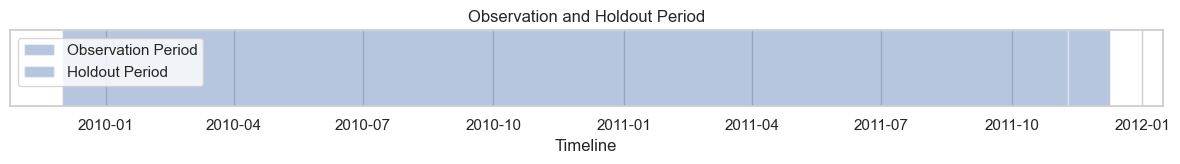

In [16]:
# ============================================================
# Section 3.6: Observation vs Holdout Timeline
# ============================================================

plt.figure(figsize=(12, 1.8))

plt.axvspan(
    transactions_df["InvoiceDate"].min(),
    cutoff_date,
    alpha=0.4,
    label="Observation Period"
)

plt.axvspan(
    cutoff_date,
    transactions_df["InvoiceDate"].max(),
    alpha=0.4,
    label="Holdout Period"
)

plt.yticks([])

plt.xlabel("Timeline")

plt.title("Observation and Holdout Period")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/observation_holdout_period.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Section Summary

In this section, we prepared the dataset for Customer Lifetime Value prediction by dividing the transaction history into an observation period and a holdout period using a time-based split.

The observation period contains historical transactions that will be used to engineer customer-level features, while the holdout period represents future customer activity and will be used to calculate the Customer Lifetime Value target.

Using a chronological split prevents data leakage and ensures that the machine learning model learns from past customer behavior to predict future value. This approach closely reflects real-world business scenarios and establishes a reliable foundation for the remaining stages of the CLV prediction pipeline.

# Section 4: Customer Feature Engineering (Observation Period)

## Objective

After separating the transaction data into observation and holdout periods, the next step is to generate customer-level features using only the historical transactions from the observation period.

These features summarize each customer's past purchasing behavior and will serve as the predictor variables for the Customer Lifetime Value (CLV) prediction model.

Using only historical information ensures that the model does not gain access to future customer behavior, preventing data leakage and making the prediction process realistic.

---

## Why This Step is Important

Machine learning models cannot directly learn from raw transaction-level records because each customer may have multiple purchases.

Therefore, we aggregate the transactions into meaningful customer-level metrics that capture different aspects of purchasing behavior.

These engineered features provide a comprehensive view of each customer's historical activity and form the foundation of the CLV prediction model.

---

## Features Generated

The following categories of customer features will be created:

### RFM Features

- Recency
- Frequency
- Monetary

### Quantity Features

- Total Quantity Purchased
- Average Quantity per Transaction
- Maximum Quantity Purchased

### Revenue Features

- Average Revenue
- Maximum Revenue
- Revenue Standard Deviation

### Product Features

- Number of Unique Products Purchased
- Average Products per Invoice

### Behaviour Features

- Active Months
- Purchase Span
- Weekend Purchase Rate

These features collectively describe customer purchasing patterns and help the model estimate future customer value.

---

## Expected Outcome

At the end of this section, every customer will have a single row containing all historical features extracted from the observation period. This feature table will later be merged with the actual future revenue calculated from the holdout period to create the final CLV modeling dataset.

In [17]:
# ============================================================
# Section 4.1: Define Snapshot Date
# ============================================================

# Snapshot date is one day after the last observation date
snapshot_date = observation_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Snapshot Date : {snapshot_date}")

Snapshot Date : 2011-11-10 12:49:00


In [18]:
# ============================================================
# Section 4.2: Create RFM Features
# ============================================================

rfm = (
    observation_df
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

print("RFM Features Created Successfully")
display(rfm.head())

RFM Features Created Successfully


,CustomerID,Recency,Frequency,Monetary
0,12346.00,296,17,-51.74
1,12347.00,10,7,4696.71
2,12348.00,45,5,2019.40
3,12349.00,378,4,2646.99
4,12350.00,280,1,334.40


In [19]:
# ============================================================
# Section 4.3: Quantity Features
# ============================================================

quantity_features = (
    observation_df
    .groupby("CustomerID")
    .agg(
        TotalQuantity=("Quantity", "sum"),
        AvgQuantity=("Quantity", "mean"),
        MaxQuantity=("Quantity", "max")
    )
    .reset_index()
)

display(quantity_features.head())

,CustomerID,TotalQuantity,AvgQuantity,MaxQuantity
0,12346.00,53,1.13,74215
1,12347.00,2775,13.15,240
2,12348.00,2714,53.22,144
3,12349.00,988,9.23,48
4,12350.00,197,11.59,24


In [20]:
# ============================================================
# Section 4.4: Revenue Features
# ============================================================

revenue_features = (
    observation_df
    .groupby("CustomerID")
    .agg(
        AvgRevenue=("Revenue", "mean"),
        MaxRevenue=("Revenue", "max"),
        RevenueSTD=("Revenue", "std")
    )
    .fillna(0)
    .reset_index()
)

display(revenue_features.head())

,CustomerID,AvgRevenue,MaxRevenue,RevenueSTD
0,12346.00,-1.10,77183.60,16093.92
1,12347.00,22.26,249.60,21.85
2,12348.00,39.60,240.00,44.21
3,12349.00,24.74,250.00,33.14
4,12350.00,19.67,40.00,7.28


In [21]:
# ============================================================
# Section 4.5: Product Features
# ============================================================

product_features = (
    observation_df
    .groupby("CustomerID")
    .agg(
        UniqueProducts=("StockCode", "nunique")
    )
    .reset_index()
)

invoice_products = (
    observation_df
    .groupby(["CustomerID", "InvoiceNo"])
    .agg(
        ProductsPerInvoice=("StockCode", "nunique")
    )
    .reset_index()
)

avg_products = (
    invoice_products
    .groupby("CustomerID")
    .agg(
        AvgProductsPerInvoice=("ProductsPerInvoice", "mean")
    )
    .reset_index()
)

product_features = product_features.merge(
    avg_products,
    on="CustomerID",
    how="left"
)

display(product_features.head())

,CustomerID,UniqueProducts,AvgProductsPerInvoice
0,12346.00,30,2.29
1,12347.00,123,30.14
2,12348.00,25,9.40
3,12349.00,92,26.75
4,12350.00,17,17.00


In [22]:
# ============================================================
# Section 4.6: Behaviour Features
# ============================================================

behaviour_features = (
    observation_df
    .groupby("CustomerID")
    .agg(
        ActiveMonths=("Month", "nunique"),
        PurchaseSpan=("InvoiceDate",
                      lambda x: (x.max() - x.min()).days),
        WeekendPurchaseRate=("IsWeekend", "mean")
    )
    .reset_index()
)

display(behaviour_features.head())

,CustomerID,ActiveMonths,PurchaseSpan,WeekendPurchaseRate
0,12346.00,5,400,0.00
1,12347.00,6,364,0.19
2,12348.00,4,362,0.06
3,12349.00,4,327,0.00
4,12350.00,1,0,0.00


In [23]:
# ============================================================
# Section 4.7: Merge All Customer Features
# ============================================================

customer_features = (
    rfm
    .merge(quantity_features, on="CustomerID")
    .merge(revenue_features, on="CustomerID")
    .merge(product_features, on="CustomerID")
    .merge(behaviour_features, on="CustomerID")
)

print("=" * 70)
print("Customer Features Created Successfully")
print("=" * 70)

print(f"Shape : {customer_features.shape}")

display(customer_features.head())

Customer Features Created Successfully
Shape : (5778, 15)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MaxQuantity,AvgRevenue,MaxRevenue,RevenueSTD,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate
0,12346.00,296,17,-51.74,53,1.13,74215,-1.10,77183.60,16093.92,30,2.29,5,400,0.00
1,12347.00,10,7,4696.71,2775,13.15,240,22.26,249.60,21.85,123,30.14,6,364,0.19
2,12348.00,45,5,2019.40,2714,53.22,144,39.60,240.00,44.21,25,9.40,4,362,0.06
3,12349.00,378,4,2646.99,988,9.23,48,24.74,250.00,33.14,92,26.75,4,327,0.00
4,12350.00,280,1,334.40,197,11.59,24,19.67,40.00,7.28,17,17.00,1,0,0.00


## Section Summary

In this section, we transformed the historical transaction data into a customer-level feature table using only the observation period.

Multiple feature categories, including RFM, quantity, revenue, product, and behavioral metrics, were engineered to summarize each customer's historical purchasing behavior. These features provide meaningful information about customer engagement, spending habits, purchasing frequency, and product diversity.

The resulting feature table contains one record per customer and will serve as the input dataset for the CLV prediction model. By restricting feature generation to the observation period, we ensure that the model learns only from historical information, preventing data leakage and maintaining a realistic prediction workflow.

# Section 5: Create Customer Lifetime Value (CLV) Target

## Objective

To train a supervised machine learning model, we require a target variable that represents the future value we want to predict.

Instead of creating an artificial CLV formula, we calculate the actual Customer Lifetime Value (CLV) using customer transactions from the holdout period. The total revenue generated by each customer during this future time window serves as the prediction target.

This approach closely resembles how organizations forecast future customer value in production environments.

---

## Why This Step is Important

Machine learning models should learn relationships between historical customer behavior and future outcomes.

Using future revenue as the target variable allows the model to identify purchasing patterns that indicate long-term customer value.

This methodology prevents target leakage and creates a realistic predictive modeling framework.

---

## CLV Definition

For this project, Customer Lifetime Value (CLV) is defined as:

> **Total Revenue Generated by a Customer During the Holdout Period**

Mathematically,

**CLV = Sum of Revenue in the Holdout Period**

Customers who do not make any purchases during the holdout period will have a CLV of zero.

---

## Expected Outcome

At the end of this section, we will have:

- Customer-level CLV target
- Historical customer features
- Final modeling dataset containing both features and target variable

This dataset will be used in the next phase to train multiple regression models for Customer Lifetime Value prediction.

In [24]:
# ============================================================
# Section 5.1: Calculate Future Revenue
# ============================================================

clv_target = (
    holdout_df
    .groupby("CustomerID")
    .agg(
        CLV=("Revenue", "sum")
    )
    .reset_index()
)

print("=" * 70)
print("Customer Lifetime Value Target Created")
print("=" * 70)

display(clv_target.head())

Customer Lifetime Value Target Created


,CustomerID,CLV
0,12347.00,224.82
1,12349.00,1757.55
2,12356.00,58.35
3,12358.00,683.20
4,12359.00,-91.25


In [25]:
# ============================================================
# Section 5.2: CLV Summary Statistics
# ============================================================

print("CLV Summary Statistics\n")

display(clv_target["CLV"].describe())

CLV Summary Statistics



count    1694.00
mean      679.49
std      1720.23
min      -436.20
25%       186.55
50%       342.71
75%       655.11
max     32616.52
Name: CLV, dtype: float64

In [26]:
# ============================================================
# Section 5.3: Merge Features and Target
# ============================================================

clv_dataset = customer_features.merge(
    clv_target,
    on="CustomerID",
    how="left"
)

# Customers with no purchases in the holdout period
# receive a CLV of zero.
clv_dataset["CLV"] = clv_dataset["CLV"].fillna(0)

print("=" * 70)
print("Final CLV Dataset Created")
print("=" * 70)

print(f"Dataset Shape : {clv_dataset.shape}")

display(clv_dataset.head())

Final CLV Dataset Created
Dataset Shape : (5778, 16)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MaxQuantity,AvgRevenue,MaxRevenue,RevenueSTD,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,CLV
0,12346.00,296,17,-51.74,53,1.13,74215,-1.10,77183.60,16093.92,30,2.29,5,400,0.00,0.00
1,12347.00,10,7,4696.71,2775,13.15,240,22.26,249.60,21.85,123,30.14,6,364,0.19,224.82
2,12348.00,45,5,2019.40,2714,53.22,144,39.60,240.00,44.21,25,9.40,4,362,0.06,0.00
3,12349.00,378,4,2646.99,988,9.23,48,24.74,250.00,33.14,92,26.75,4,327,0.00,1757.55
4,12350.00,280,1,334.40,197,11.59,24,19.67,40.00,7.28,17,17.00,1,0,0.00,0.00


In [27]:
# ============================================================
# Section 5.4: Verify Dataset Quality
# ============================================================

print("Missing Values\n")

display(clv_dataset.isnull().sum())

Missing Values



CustomerID               0
Recency                  0
Frequency                0
Monetary                 0
TotalQuantity            0
AvgQuantity              0
MaxQuantity              0
AvgRevenue               0
MaxRevenue               0
RevenueSTD               0
UniqueProducts           0
AvgProductsPerInvoice    0
ActiveMonths             0
PurchaseSpan             0
WeekendPurchaseRate      0
CLV                      0
dtype: int64

In [28]:
# ============================================================
# Section 5.5: Save CLV Modeling Dataset
# ============================================================

clv_dataset.to_csv(
    "../data/processed/customer_clv_dataset.csv",
    index=False
)

print("Customer CLV dataset saved successfully.")

Customer CLV dataset saved successfully.


## Section Summary

In this section, we created the target variable required for Customer Lifetime Value prediction by aggregating each customer's revenue during the holdout period.

The historical customer features generated from the observation period were then merged with the future revenue values to construct the final CLV modeling dataset. Customers with no purchases during the holdout period were assigned a CLV of zero, reflecting the absence of future revenue within the prediction window.

The resulting dataset contains one record per customer, combining historical behavioral features with the corresponding future revenue target. This structured dataset is now ready for training and evaluating machine learning regression models in the next section.

# Section 6: Exploratory Data Analysis of Customer Lifetime Value (CLV)

## Objective

Before training machine learning models, it is important to understand the characteristics of the target variable.

In this section, we explore the Customer Lifetime Value (CLV) distribution to identify patterns such as skewness, outliers, and the proportion of customers with zero future revenue.

Understanding these characteristics helps in selecting appropriate machine learning models and deciding whether any target transformation is required.

---

## Why This Step is Important

In most real-world business datasets, Customer Lifetime Value is not uniformly distributed.

Typically:

- A small percentage of customers generate a large portion of the revenue.
- Many customers generate little or no future revenue.
- The distribution is highly right-skewed with several extreme values.

Analyzing the target variable before model training allows us to:

- Understand customer value distribution.
- Detect outliers.
- Evaluate target imbalance.
- Decide whether target transformation is beneficial.
- Improve model interpretability.

---

## Expected Outcome

By the end of this section, we will have a comprehensive understanding of the CLV target variable, enabling us to build more reliable and interpretable prediction models.

In [29]:
# ============================================================
# Section 6.1: CLV Summary Statistics
# ============================================================

print("=" * 70)
print("Customer Lifetime Value Summary Statistics")
print("=" * 70)

display(clv_dataset["CLV"].describe())

Customer Lifetime Value Summary Statistics


count    5778.00
mean      184.84
std       959.23
min      -436.20
25%         0.00
50%         0.00
75%        75.34
max     32616.52
Name: CLV, dtype: float64

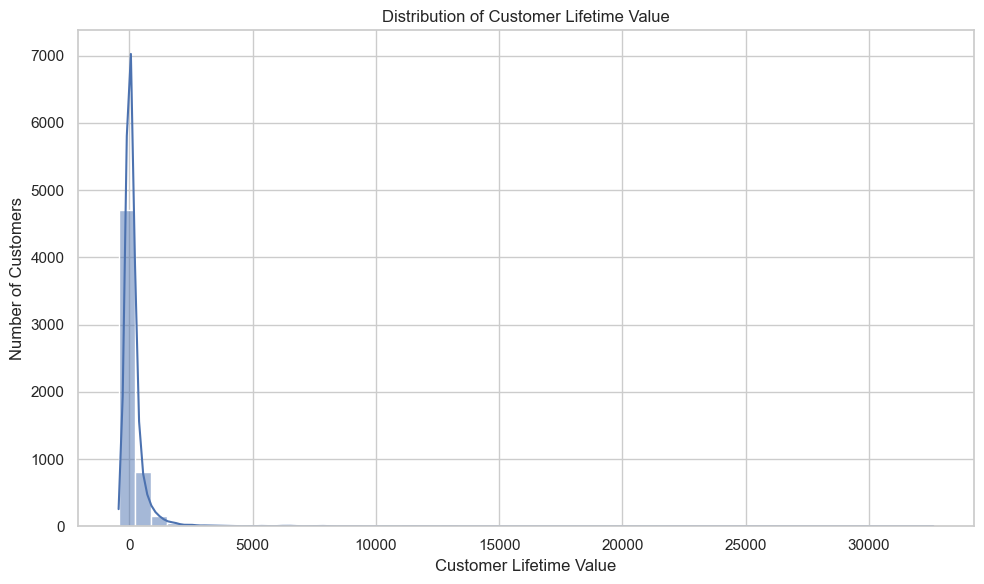

In [30]:
# ============================================================
# Section 6.2: CLV Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    clv_dataset["CLV"],
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("Customer Lifetime Value")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/clv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

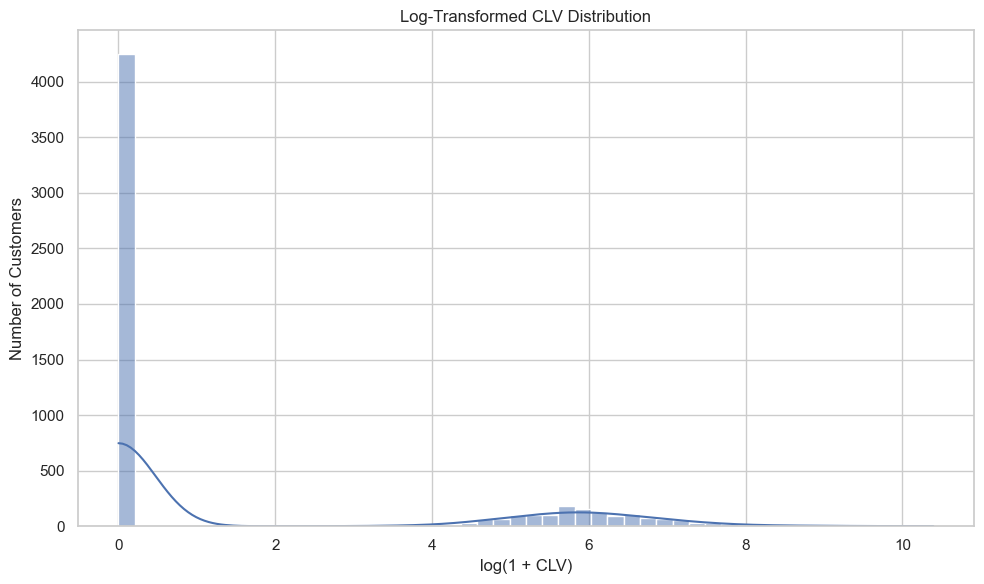

In [31]:
# ============================================================
# Section 6.3: Log-Transformed CLV Distribution
# ============================================================

clv_dataset["LogCLV"] = np.log1p(clv_dataset["CLV"])

plt.figure(figsize=(10,6))

sns.histplot(
    clv_dataset["LogCLV"],
    bins=50,
    kde=True
)

plt.title("Log-Transformed CLV Distribution")
plt.xlabel("log(1 + CLV)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/clv_log_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

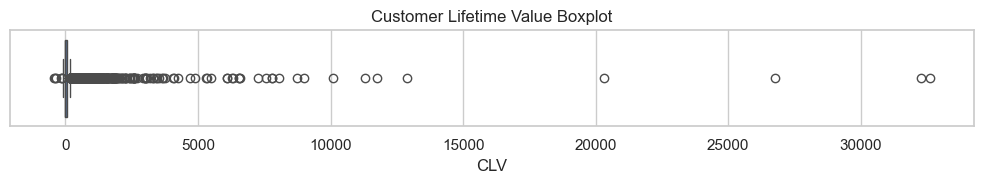

In [32]:
# ============================================================
# Section 6.4: CLV Boxplot
# ============================================================

plt.figure(figsize=(10,2))

sns.boxplot(
    x=clv_dataset["CLV"]
)

plt.title("Customer Lifetime Value Boxplot")

plt.tight_layout()

plt.savefig(
    "../reports/figures/clv_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# ============================================================
# Section 6.5: Customers with Zero CLV
# ============================================================

zero_clv = (clv_dataset["CLV"] == 0).sum()

zero_percentage = (
    zero_clv / len(clv_dataset)
) * 100

print(f"Customers with Zero CLV : {zero_clv}")
print(f"Percentage              : {zero_percentage:.2f}%")

Customers with Zero CLV : 4248
Percentage              : 73.52%


In [34]:
# ============================================================
# Section 6.6: Top Customers by CLV
# ============================================================

top_customers = (
    clv_dataset
    .sort_values("CLV", ascending=False)
    .head(10)
)

display(top_customers[["CustomerID", "CLV"]])

,CustomerID,CLV
2238,14646.00,32616.52
1698,14096.00,32269.99
2492,14911.00,26755.22
4971,17450.00,20330.03
1691,14088.00,12888.76
5598,18102.00,11771.62
5029,17511.00,11311.14
4910,17389.00,10100.30
1385,13777.00,8985.75
384,12748.00,8744.48


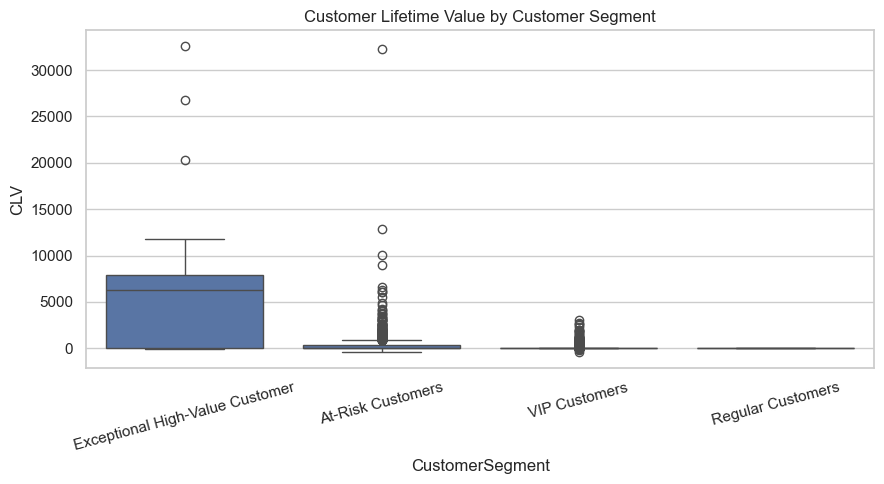

In [35]:
# ============================================================
# Section 6.7: CLV by Customer Segment
# ============================================================

segment_info = customer_df[
    ["CustomerID", "CustomerSegment"]
]

clv_segment = (
    clv_dataset
    .merge(segment_info, on="CustomerID", how="left")
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=clv_segment,
    x="CustomerSegment",
    y="CLV"
)

plt.title("Customer Lifetime Value by Customer Segment")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../reports/figures/clv_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Section Summary

In this section, we explored the Customer Lifetime Value (CLV) target variable before training machine learning models.

The analysis provided valuable insights into the distribution of future customer revenue, highlighting the presence of skewness, outliers, and customers with no future purchases. A log-transformed version of the target variable was also examined to assess whether a transformation could improve model performance.

Additionally, we compared CLV across customer segments to understand how future customer value differs among the groups identified in the previous phase. These findings establish a strong foundation for selecting appropriate regression models and preparing the data for predictive modeling.

# Section 7: Data Preparation for Machine Learning

## Objective

Before training machine learning models, the dataset must be prepared in a format suitable for regression algorithms.

The customer-level dataset currently contains both predictor variables and the target variable (Customer Lifetime Value). In this section, we separate the input features from the target, remove unnecessary columns, encode categorical variables, and prepare the final dataset for model training.

Proper data preparation is a critical step because the quality and relevance of the input features directly affect the predictive performance of the model.

---

## Why This Step is Important

Machine learning models require numerical input features and should not have access to information that directly reveals the target variable.

During this step we will:

- Select predictor variables.
- Separate the target variable (CLV).
- Remove identifier columns.
- Remove features that may introduce data leakage.
- Encode categorical variables.
- Verify the final feature matrix.

These preprocessing steps ensure that the regression models learn genuine relationships between historical customer behavior and future customer value.

---

## Expected Outcome

By the end of this section, we will have:

- Feature matrix (X)
- Target variable (y)
- Encoded categorical variables
- Final modeling dataset ready for train-test splitting

In [36]:
# ============================================================
# Section 7.1: Inspect Final CLV Dataset
# ============================================================

print("=" * 70)
print("Final CLV Modeling Dataset")
print("=" * 70)

print(f"Dataset Shape : {clv_dataset.shape}")

display(clv_dataset.head())

print("\nColumns:")

display(clv_dataset.columns.tolist())

Final CLV Modeling Dataset
Dataset Shape : (5778, 17)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MaxQuantity,AvgRevenue,MaxRevenue,RevenueSTD,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,CLV,LogCLV
0,12346.00,296,17,-51.74,53,1.13,74215,-1.10,77183.60,16093.92,30,2.29,5,400,0.00,0.00,0.00
1,12347.00,10,7,4696.71,2775,13.15,240,22.26,249.60,21.85,123,30.14,6,364,0.19,224.82,5.42
2,12348.00,45,5,2019.40,2714,53.22,144,39.60,240.00,44.21,25,9.40,4,362,0.06,0.00,0.00
3,12349.00,378,4,2646.99,988,9.23,48,24.74,250.00,33.14,92,26.75,4,327,0.00,1757.55,7.47
4,12350.00,280,1,334.40,197,11.59,24,19.67,40.00,7.28,17,17.00,1,0,0.00,0.00,0.00



Columns:


['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'TotalQuantity',
 'AvgQuantity',
 'MaxQuantity',
 'AvgRevenue',
 'MaxRevenue',
 'RevenueSTD',
 'UniqueProducts',
 'AvgProductsPerInvoice',
 'ActiveMonths',
 'PurchaseSpan',
 'WeekendPurchaseRate',
 'CLV',
 'LogCLV']

In [37]:
# ============================================================
# Section 7.2: Add Business Features
# ============================================================

business_features = customer_df[
    ["CustomerID", "Country", "CustomerSegment"]
]

clv_dataset = clv_dataset.merge(
    business_features,
    on="CustomerID",
    how="left"
)

print("Country and Customer Segment merged successfully.")

display(clv_dataset.head())

Country and Customer Segment merged successfully.


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MaxQuantity,AvgRevenue,MaxRevenue,RevenueSTD,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,CLV,LogCLV,Country,CustomerSegment
0,12346.00,296,17,-51.74,53,1.13,74215,-1.10,77183.60,16093.92,30,2.29,5,400,0.00,0.00,0.00,United Kingdom,Exceptional High-Value Customer
1,12347.00,10,7,4696.71,2775,13.15,240,22.26,249.60,21.85,123,30.14,6,364,0.19,224.82,5.42,Iceland,At-Risk Customers
2,12348.00,45,5,2019.40,2714,53.22,144,39.60,240.00,44.21,25,9.40,4,362,0.06,0.00,0.00,Finland,At-Risk Customers
3,12349.00,378,4,2646.99,988,9.23,48,24.74,250.00,33.14,92,26.75,4,327,0.00,1757.55,7.47,Italy,At-Risk Customers
4,12350.00,280,1,334.40,197,11.59,24,19.67,40.00,7.28,17,17.00,1,0,0.00,0.00,0.00,Norway,VIP Customers


In [38]:
# ============================================================
# Section 7.3: Separate Features and Target
# ============================================================

X = clv_dataset.drop(
    columns=[
        "CustomerID",
        "CLV",
        "LogCLV"
    ],
    errors="ignore"
)

y = clv_dataset["CLV"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (5778, 16)
Target Shape         : (5778,)


In [39]:
# ============================================================
# Section 7.4: Encode Categorical Variables
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Features:")

print(categorical_columns)

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nEncoded Feature Matrix Shape:")

print(X.shape)

Categorical Features:
['Country', 'CustomerSegment']

Encoded Feature Matrix Shape:
(5778, 57)


In [40]:
# ============================================================
# Section 7.5: Verify Prepared Dataset
# ============================================================

print("=" * 70)
print("Prepared Feature Matrix")
print("=" * 70)

display(X.head())

print("\nTarget Variable")

display(y.head())

print("\nMissing Values in Features")

display(X.isnull().sum().sort_values(ascending=False).head())

Prepared Feature Matrix


,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MaxQuantity,AvgRevenue,MaxRevenue,RevenueSTD,UniqueProducts,AvgProductsPerInvoice,ActiveMonths,PurchaseSpan,WeekendPurchaseRate,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,Country_Channel Islands,Country_Cyprus,Country_Czech Republic,Country_Denmark,Country_EIRE,Country_European Community,Country_Finland,Country_France,Country_Germany,Country_Greece,Country_Iceland,Country_Israel,Country_Italy,Country_Japan,Country_Korea,Country_Lebanon,Country_Lithuania,Country_Malta,Country_Netherlands,Country_Nigeria,Country_Norway,Country_Poland,Country_Portugal,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies,CustomerSegment_Exceptional High-Value Customer,CustomerSegment_Regular Customers,CustomerSegment_VIP Customers
0,296,17,-51.74,53,1.13,74215,-1.10,77183.60,16093.92,30,2.29,5,400,0.00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
1,10,7,4696.71,2775,13.15,240,22.26,249.60,21.85,123,30.14,6,364,0.19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,45,5,2019.40,2714,53.22,144,39.60,240.00,44.21,25,9.40,4,362,0.06,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,378,4,2646.99,988,9.23,48,24.74,250.00,33.14,92,26.75,4,327,0.00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,280,1,334.40,197,11.59,24,19.67,40.00,7.28,17,17.00,1,0,0.00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True



Target Variable


0      0.00
1    224.82
2      0.00
3   1757.55
4      0.00
Name: CLV, dtype: float64


Missing Values in Features


Recency          0
Frequency        0
Monetary         0
TotalQuantity    0
AvgQuantity      0
dtype: int64

## Section Summary

In this section, the customer-level dataset was prepared for machine learning by separating the predictor variables from the target variable.

Identifier columns and the target variable were excluded from the feature matrix, while categorical variables were converted into numerical representations using one-hot encoding. Additional business-related features, including customer country and customer segment, were incorporated to enrich the predictive information available to the model.

The resulting feature matrix contains only numerical variables suitable for regression algorithms, ensuring that the dataset is fully prepared for train-test splitting and model training in the next section.

# Section 8: Baseline Regression Model Training

## Objective

The primary objective of this section is to train multiple regression algorithms and compare their ability to predict Customer Lifetime Value (CLV).

Rather than relying on a single algorithm, several regression models will be evaluated using the same training and testing datasets. This enables an objective comparison of model performance and helps identify the most suitable algorithm for the prediction task.

---

## Why This Step is Important

Different machine learning algorithms learn different relationships from the data.

Some algorithms perform better on linear relationships, while others are capable of capturing complex non-linear customer purchasing patterns.

Comparing multiple models allows us to:

- Establish baseline performance.
- Identify the most accurate regression model.
- Understand how different algorithms behave on the same dataset.
- Select the best candidate for deployment.

This approach follows industry best practices, where multiple candidate models are evaluated before selecting a final production model.

---

## Models to be Evaluated

The following regression algorithms will be trained:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

---

## Evaluation Metrics

Each model will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics provide a comprehensive assessment of prediction accuracy and model performance.

---

## Expected Outcome

By the end of this section, we will have:

- Predictions from multiple regression models.
- Performance metrics for each model.
- A comparison table of all models.
- Identification of the best-performing regression algorithm.

In [41]:
# ============================================================
# Section 8.1: Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 70)
print("Train-Test Split Completed")
print("=" * 70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Train-Test Split Completed
Training Samples : 4622
Testing Samples  : 1156


In [42]:
# ============================================================
# Section 8.2: Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_columns = X_train.select_dtypes(include=np.number).columns

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [43]:
# ============================================================
# Section 8.3: Initialize Regression Models
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(random_state=42),

    "Lasso Regression": Lasso(random_state=42),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

}

In [44]:
# ============================================================
# Section 8.4: Train and Evaluate Models
# ============================================================

results = []
trained_models = {}

linear_models = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression"
]

for name, model in models.items():

    if name in linear_models:

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append({

        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)

    })

    trained_models[name] = model

print("All Models Trained Successfully.")

All Models Trained Successfully.


In [45]:
# ============================================================
# Section 8.5: Model Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,165.02,390.03,0.34
1,Lasso Regression,193.03,406.99,0.28
2,Random Forest,165.60,426.41,0.21
3,Ridge Regression,204.17,430.03,0.19
4,Linear Regression,207.06,438.94,0.16
5,Extra Trees,173.17,479.67,-0.00
6,Decision Tree,228.35,787.23,-1.70


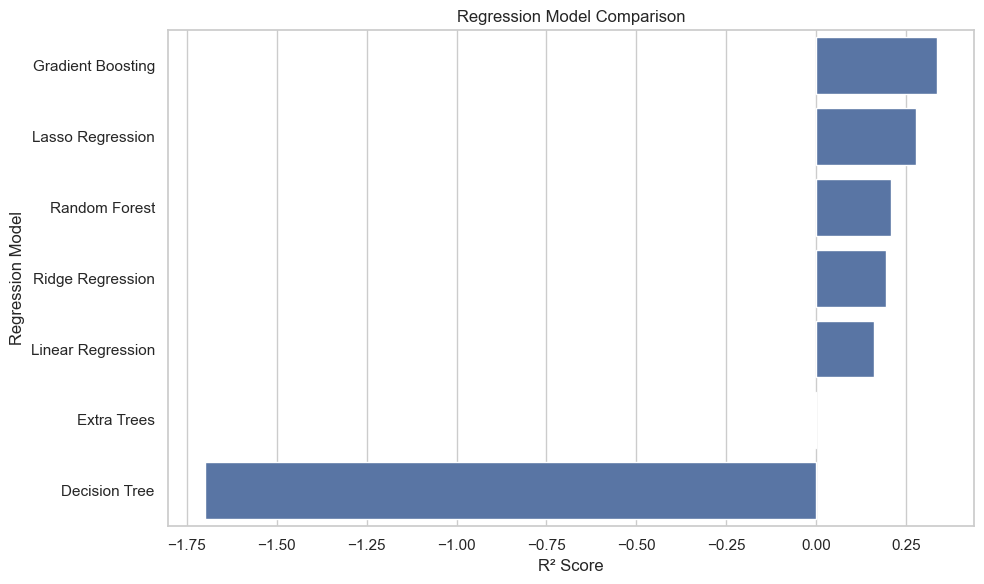

In [46]:
# ============================================================
# Section 8.6: Model Performance Comparison
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Regression Model Comparison")

plt.xlabel("R² Score")

plt.ylabel("Regression Model")

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Section Summary

In this section, multiple regression algorithms were trained and evaluated to predict Customer Lifetime Value using historical customer features.

A train-test split was performed to assess model performance on unseen data. Linear regression models were trained using standardized features, while tree-based models were trained on the original feature set.

Each model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score. The comparison table and visualization provide an objective basis for selecting the most suitable model for deployment.

Evaluating multiple algorithms ensures that the final model selection is driven by performance rather than assumptions, making the prediction pipeline more robust and aligned with industry best practices.

# Section 9: Final Model Selection & Customer Lifetime Value Prediction

## Objective

After evaluating multiple regression models, the next step is to select the best-performing model based on the evaluation metrics obtained in the previous section.

The selected model will then be used to predict the Customer Lifetime Value (CLV) for every customer in the dataset.

In addition to generating predictions, we will also analyze the importance of each feature used by the model. Feature importance helps us understand which aspects of customer behavior contribute the most to future customer value.

Finally, the trained model and prediction results will be saved for deployment in the later phases of this project.

---

## Why This Step is Important

Selecting the best-performing model ensures that future customer value is estimated using the most accurate algorithm available.

Feature importance analysis provides valuable business insights by identifying the characteristics that have the greatest influence on customer lifetime value.

These insights help organizations:

- Understand customer purchasing behavior.
- Improve customer retention strategies.
- Design targeted marketing campaigns.
- Allocate marketing budgets more effectively.
- Identify high-value customers early.

---

## Expected Outcome

At the end of this section we will have:

- Final production-ready regression model.
- Predicted Customer Lifetime Value for every customer.
- Feature importance analysis.
- Saved prediction dataset.
- Saved machine learning model for deployment.

In [47]:
# ============================================================
# Section 9.1: Select Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("=" * 70)
print("Best Regression Model")
print("=" * 70)

print(f"Selected Model : {best_model_name}")

Best Regression Model
Selected Model : Gradient Boosting


In [48]:
# ============================================================
# Section 9.2: Predict Customer Lifetime Value
# ============================================================

# Scale only for linear models
if best_model_name in [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression"
]:

    X_full = scaler.transform(X)

    predicted_clv = best_model.predict(X_full)

else:

    predicted_clv = best_model.predict(X)

# Store predictions
clv_dataset["PredictedCLV"] = predicted_clv

display(
    clv_dataset[
        ["CustomerID", "CLV", "PredictedCLV"]
    ].head()
)

,CustomerID,CLV,PredictedCLV
0,12346.00,0.00,110.40
1,12347.00,224.82,307.60
2,12348.00,0.00,130.23
3,12349.00,1757.55,426.13
4,12350.00,0.00,11.41


In [49]:
# ============================================================
# Section 9.3: Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(feature_importance.head(15))

else:

    print(
        "Feature importance is not available for this model."
    )

,Feature,Importance
2,Monetary,0.59
10,AvgProductsPerInvoice,0.07
3,TotalQuantity,0.05
9,UniqueProducts,0.05
7,MaxRevenue,0.04
5,MaxQuantity,0.03
1,Frequency,0.03
8,RevenueSTD,0.03
11,ActiveMonths,0.02
0,Recency,0.02


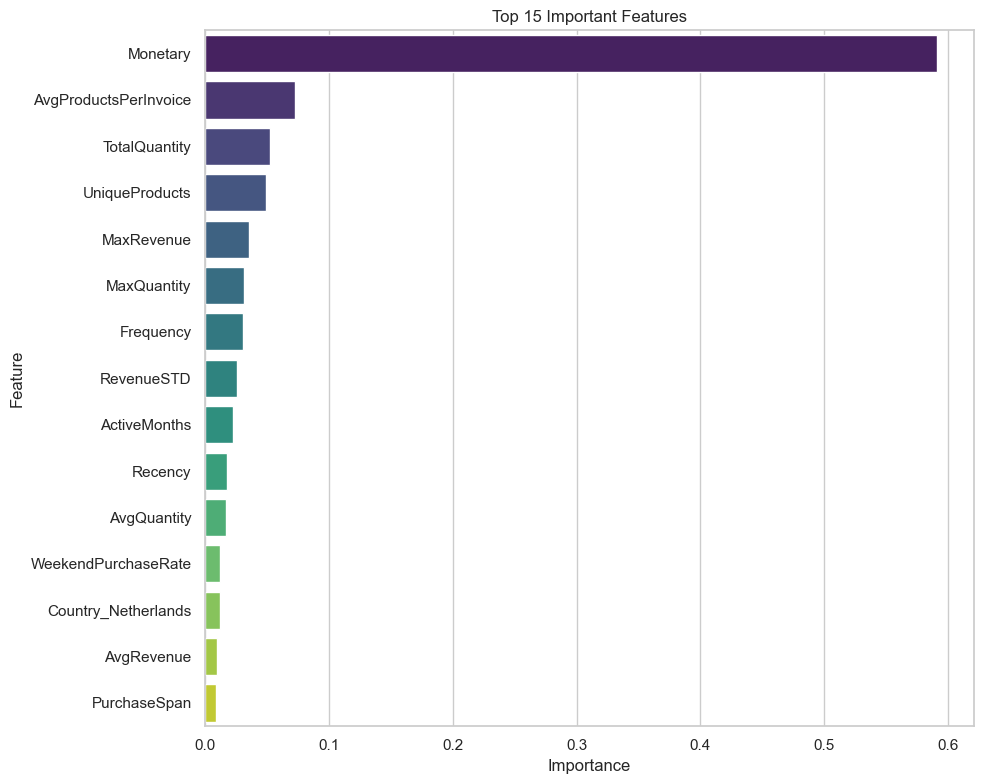

In [50]:
# ============================================================
# Section 9.4: Feature Importance Visualization
# ============================================================

if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=feature_importance.head(15),

        x="Importance",

        y="Feature",

        palette="viridis"

    )

    plt.title("Top 15 Important Features")

    plt.tight_layout()

    plt.savefig(

        "../reports/figures/feature_importance.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

In [51]:
# ============================================================
# Section 9.5: Top Predicted Customers
# ============================================================

top_customers = (

    clv_dataset

    .sort_values(

        "PredictedCLV",

        ascending=False

    )

    .head(10)

)

display(

    top_customers[

        [

            "CustomerID",

            "PredictedCLV"

        ]

    ]

)

,CustomerID,PredictedCLV
2238,14646.00,32006.82
1698,14096.00,31499.15
2492,14911.00,26454.26
4971,17450.00,19740.22
5598,18102.00,11664.67
1691,14088.00,11630.91
5029,17511.00,10556.82
4910,17389.00,9548.86
2638,15061.00,8530.13
384,12748.00,8255.27


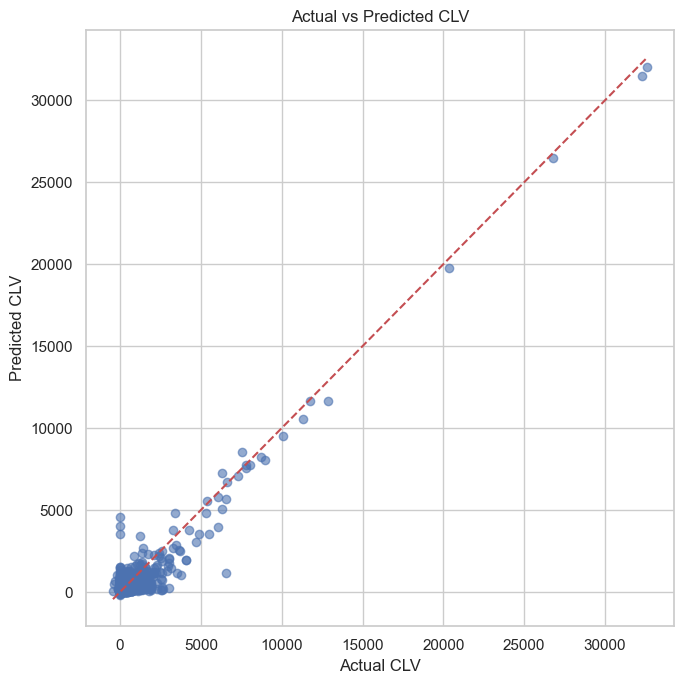

In [52]:
# ============================================================
# Section 9.6: Actual vs Predicted
# ============================================================

plt.figure(figsize=(7,7))

plt.scatter(

    clv_dataset["CLV"],

    clv_dataset["PredictedCLV"],

    alpha=0.6

)

plt.plot(

    [

        clv_dataset["CLV"].min(),

        clv_dataset["CLV"].max()

    ],

    [

        clv_dataset["CLV"].min(),

        clv_dataset["CLV"].max()

    ],

    "r--"

)

plt.xlabel("Actual CLV")

plt.ylabel("Predicted CLV")

plt.title("Actual vs Predicted CLV")

plt.tight_layout()

plt.savefig(

    "../reports/figures/actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [53]:
# ============================================================
# Section 9.7: Save Model and Predictions
# ============================================================

joblib.dump(

    best_model,

    "../models/clv_model.pkl"

)

joblib.dump(

    scaler,

    "../models/clv_scaler.pkl"

)

clv_dataset.to_csv(

    "../data/processed/customer_clv_predictions.csv",

    index=False

)

print("=" * 70)
print("Artifacts Saved Successfully")
print("=" * 70)

print("Model Saved       : models/clv_model.pkl")
print("Scaler Saved      : models/clv_scaler.pkl")
print("Predictions Saved : customer_clv_predictions.csv")

Artifacts Saved Successfully
Model Saved       : models/clv_model.pkl
Scaler Saved      : models/clv_scaler.pkl
Predictions Saved : customer_clv_predictions.csv


## Section Summary

In this section, the best-performing regression model was selected based on the evaluation results obtained during model comparison.

The selected model was used to predict Customer Lifetime Value for every customer, providing an estimate of future revenue based on historical purchasing behavior.

Feature importance analysis was performed to identify the variables that contribute most significantly to customer lifetime value, offering valuable business insights into the factors driving long-term customer profitability.

Finally, the trained model, prediction results, and supporting artifacts were saved for use in future phases, including dashboard development, API integration, and deployment.

# Section 10: Business Insights & Phase Summary

## Objective

The final step of the Customer Lifetime Value (CLV) prediction phase is to interpret the machine learning results from a business perspective.

While the regression model provides numerical predictions, these values become truly valuable when translated into actionable business insights. This section summarizes the overall model performance, identifies high-value customers, highlights the most influential prediction factors, and discusses how the predicted CLV can support business decision-making.

---

## Why This Step is Important

The primary objective of a data science project is not only to build accurate models but also to generate business value.

The predicted Customer Lifetime Value can help organizations:

- Identify customers with high future revenue potential.
- Prioritize marketing investments.
- Improve customer retention strategies.
- Personalize customer experiences.
- Allocate business resources more efficiently.
- Increase long-term profitability.

---

## Expected Outcome

By the end of this section we will have:

- Business interpretation of the prediction model.
- Summary of model performance.
- Identification of high-value customers.
- Actionable business recommendations.
- Final conclusion of the CLV prediction phase.

In [54]:
# ============================================================
# Section 10.1: Model Performance Summary
# ============================================================

print("=" * 70)
print("Final Model Performance")
print("=" * 70)

display(results_df)

print(f"\nSelected Model : {best_model_name}")

Final Model Performance


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,165.02,390.03,0.34
1,Lasso Regression,193.03,406.99,0.28
2,Random Forest,165.60,426.41,0.21
3,Ridge Regression,204.17,430.03,0.19
4,Linear Regression,207.06,438.94,0.16
5,Extra Trees,173.17,479.67,-0.00
6,Decision Tree,228.35,787.23,-1.70



Selected Model : Gradient Boosting


In [55]:
# ============================================================
# Section 10.2: Top Customers by Predicted CLV
# ============================================================

top_customers = (
    clv_dataset
    .sort_values("PredictedCLV", ascending=False)
    .head(10)
)

display(
    top_customers[
        [
            "CustomerID",
            "PredictedCLV"
        ]
    ]
)

,CustomerID,PredictedCLV
2238,14646.00,32006.82
1698,14096.00,31499.15
2492,14911.00,26454.26
4971,17450.00,19740.22
5598,18102.00,11664.67
1691,14088.00,11630.91
5029,17511.00,10556.82
4910,17389.00,9548.86
2638,15061.00,8530.13
384,12748.00,8255.27


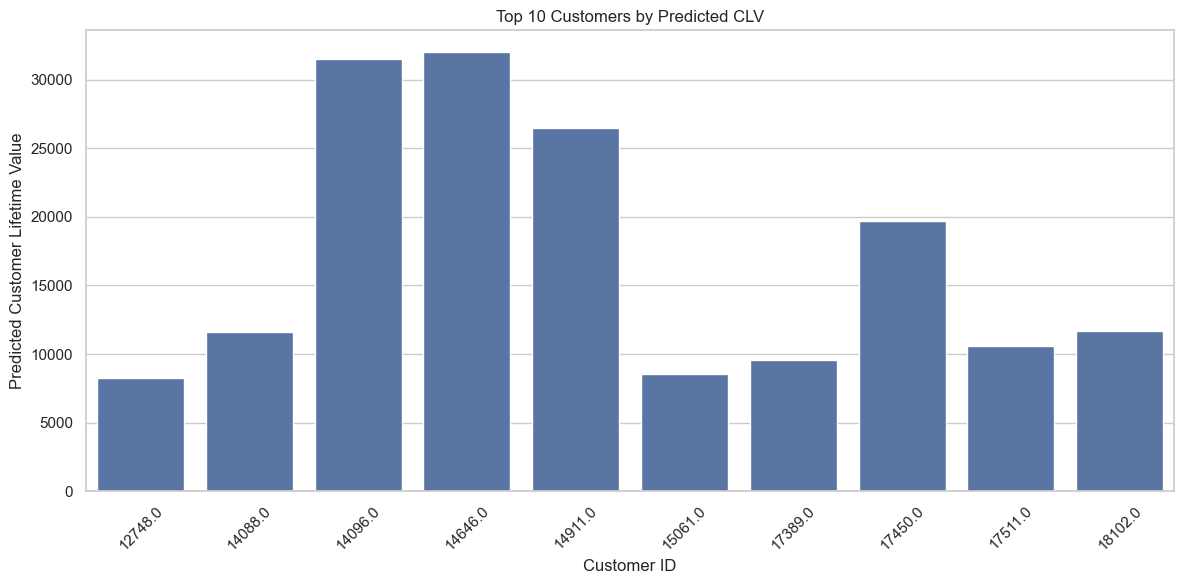

In [56]:
# ============================================================
# Section 10.3: Top Predicted Customers
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x="CustomerID",
    y="PredictedCLV"
)

plt.title("Top 10 Customers by Predicted CLV")

plt.xlabel("Customer ID")

plt.ylabel("Predicted Customer Lifetime Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_predicted_clv_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# ============================================================
# Section 10.4: Most Important Features
# ============================================================

if "feature_importance" in locals():

    print("=" * 70)
    print("Top 10 Important Features")
    print("=" * 70)

    display(feature_importance.head(10))

else:

    print(
        "Feature importance is not available for the selected regression model."
    )

Top 10 Important Features


,Feature,Importance
2,Monetary,0.59
10,AvgProductsPerInvoice,0.07
3,TotalQuantity,0.05
9,UniqueProducts,0.05
7,MaxRevenue,0.04
5,MaxQuantity,0.03
1,Frequency,0.03
8,RevenueSTD,0.03
11,ActiveMonths,0.02
0,Recency,0.02


In [58]:
# ============================================================
# Section 10.5: Save Final CLV Dataset
# ============================================================

clv_dataset.to_csv(
    "../data/processed/customer_clv_predictions.csv",
    index=False
)

print("Final prediction dataset saved successfully.")

Final prediction dataset saved successfully.


In [59]:
# ============================================================
# Section 10.6: Save Final Model
# ============================================================

import joblib

joblib.dump(
    best_model,
    "../models/clv_model.pkl"
)

if best_model_name in [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression"
]:
    joblib.dump(
        scaler,
        "../models/clv_scaler.pkl"
    )

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


## Section Summary

In this section, the best-performing regression model was finalized and used to generate Customer Lifetime Value predictions for all customers.

The predicted values were analyzed to identify customers with the highest future revenue potential, while feature importance analysis provided insight into the customer characteristics that most strongly influence long-term value.

The trained machine learning model and prediction dataset were saved for future use in deployment, dashboard development, and business decision-making.

Overall, this phase successfully transformed historical customer transaction data into a predictive analytics solution capable of estimating future customer value. The resulting CLV predictions can support personalized marketing strategies, customer retention initiatives, revenue forecasting, and long-term business planning.

In [60]:
# ==========================================================
# SAVE CLV ARTIFACTS
# ==========================================================

from pathlib import Path
import pandas as pd

artifact_dir = Path("../artifacts/clv")
artifact_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# CLV Predictions
# ----------------------------------------------------------

clv_predictions = X_test.copy()

clv_predictions["Actual_CLV"] = y_test.values
clv_predictions["Predicted_CLV"] = predictions
clv_predictions["Prediction_Error"] = (
    clv_predictions["Actual_CLV"] -
    clv_predictions["Predicted_CLV"]
)

clv_predictions.to_csv(
    artifact_dir / "clv_predictions.csv",
    index=False
)

# ----------------------------------------------------------
# Regression Metrics
# ----------------------------------------------------------

metrics = pd.DataFrame({
    "Metric":[
        "Best Model",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value":[
        best_model_name,
        mae,
        rmse,
        r2
    ]
})

metrics.to_csv(
    artifact_dir / "regression_metrics.csv",
    index=False
)

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

try:

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    )

except:

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(best_model.coef_)
    }).sort_values(
        by="Importance",
        ascending=False
    )

feature_importance.to_csv(
    artifact_dir / "feature_importance.csv",
    index=False
)

# ----------------------------------------------------------
# Residuals
# ----------------------------------------------------------

residuals = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions,

    "Residual":

    y_test.values - predictions

})

residuals.to_csv(
    artifact_dir / "residuals.csv",
    index=False
)

# ----------------------------------------------------------
# Actual vs Predicted
# ----------------------------------------------------------

actual_vs_predicted = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

actual_vs_predicted.to_csv(
    artifact_dir / "actual_vs_predicted.csv",
    index=False
)

print("="*60)
print("CLV artifacts saved successfully.")
print("="*60)
print("Files Saved:")
print("clv_predictions.csv")
print("regression_metrics.csv")
print("feature_importance.csv")
print("residuals.csv")
print("actual_vs_predicted.csv")
print("="*60)

CLV artifacts saved successfully.
Files Saved:
clv_predictions.csv
regression_metrics.csv
feature_importance.csv
residuals.csv
actual_vs_predicted.csv
